In [2]:
!pip install pandas scikit-learn matplotlib seaborn imbalanced-learn

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, accuracy_score, recall_score

from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

In [4]:
from google.colab import files
uploaded = files.upload()

import io
df = pd.read_csv(io.BytesIO(uploaded[list(uploaded.keys())[0]]))

df.head()

Saving heart.csv to heart.csv


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [5]:
df = df.dropna()
df.columns = df.columns.str.replace(" ", "_")

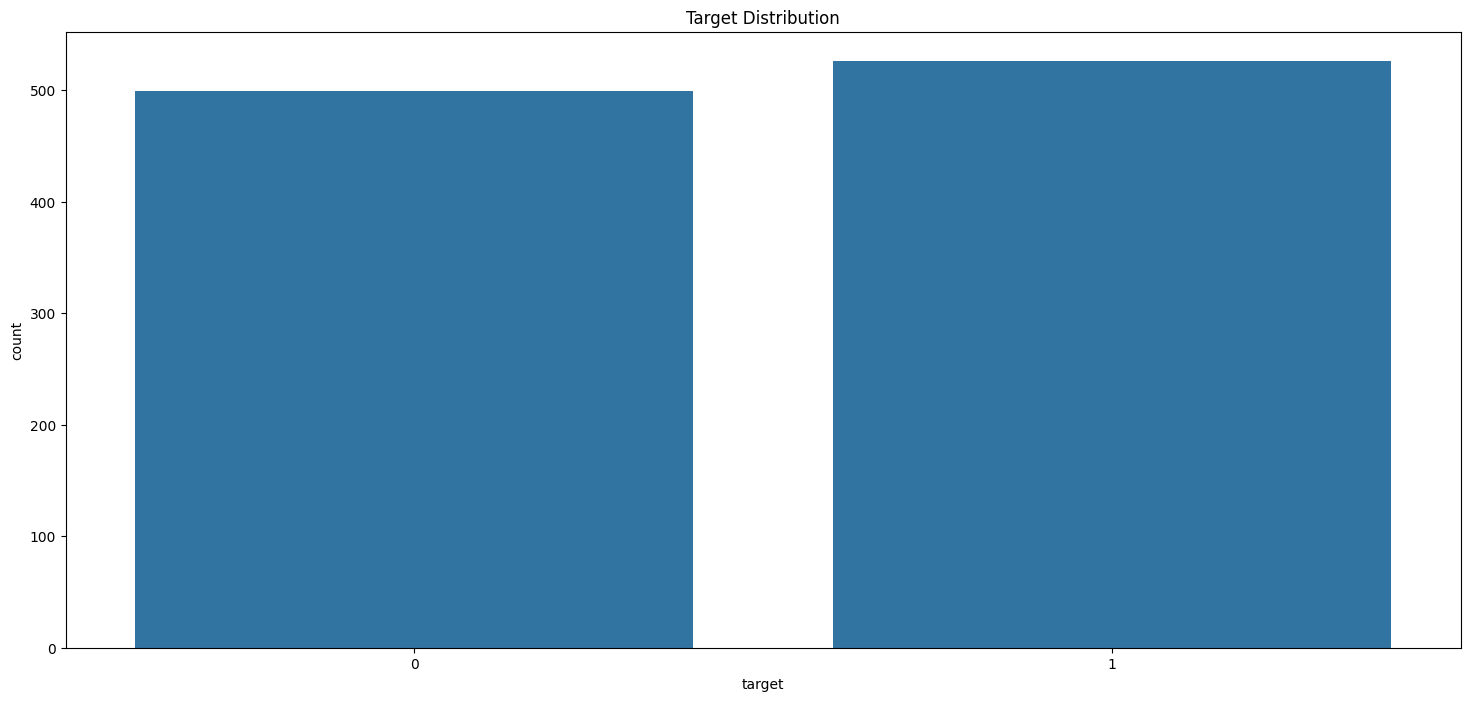

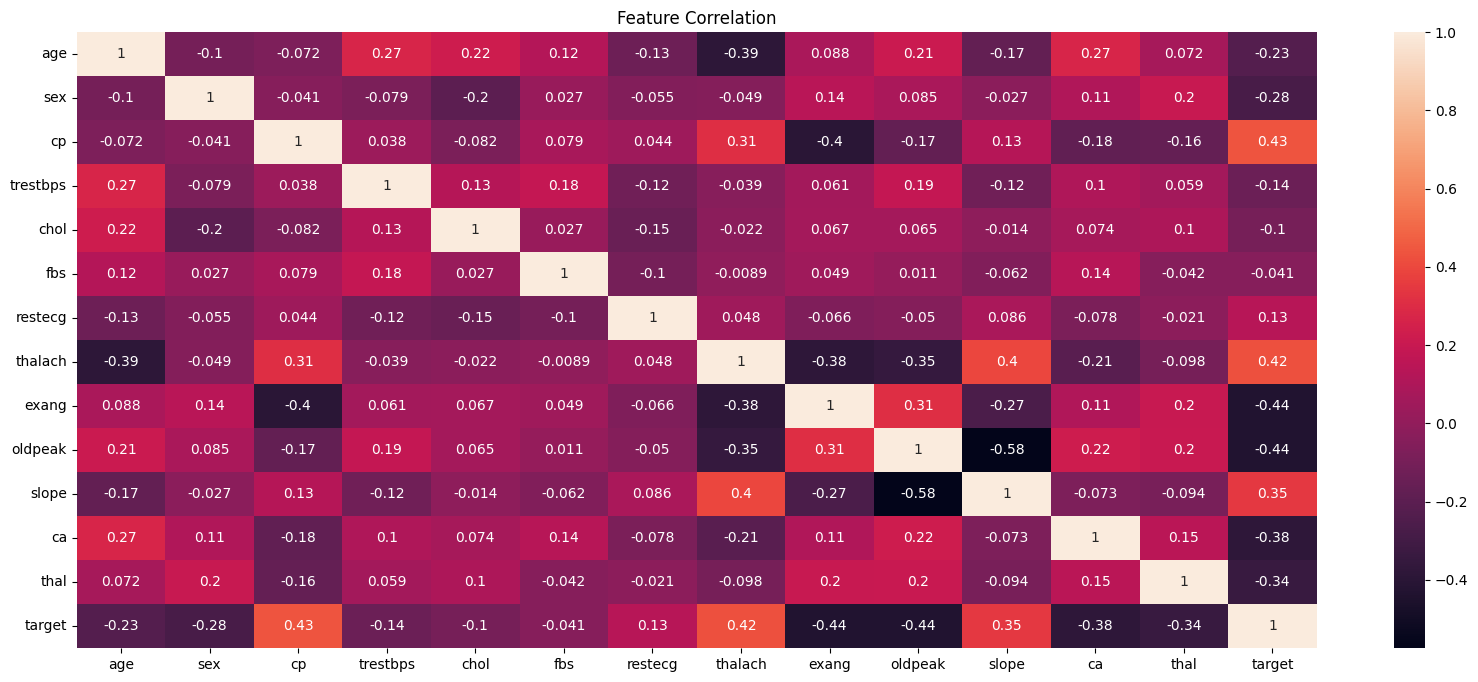

In [6]:
plt.figure(figsize=(18,8))
sns.countplot(x='target', data=df)
plt.title("Target Distribution")
plt.show()

plt.figure(figsize=(20,8))
sns.heatmap(df.corr(), annot=True)
plt.title("Feature Correlation")
plt.show()

In [7]:
X = df.drop("target", axis=1)
y = df["target"]

In [8]:


kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

acc_scores = []
recall_scores = []

for fold, (train_idx, test_idx) in enumerate(kf.split(X, y)):

    print(f"\n Fold {fold+1}")


    X_train_cv = X.iloc[train_idx]
    X_test_cv = X.iloc[test_idx]
    y_train_cv = y.iloc[train_idx]
    y_test_cv = y.iloc[test_idx]


    scaler_cv = StandardScaler()
    X_train_cv = scaler_cv.fit_transform(X_train_cv)
    X_test_cv = scaler_cv.transform(X_test_cv)





    model_cv = RandomForestClassifier(
        n_estimators=300,
        max_depth=7,
        random_state=42
    )


    model_cv.fit(X_train_cv, y_train_cv)


    y_pred_cv = model_cv.predict(X_test_cv)


    acc = accuracy_score(y_test_cv, y_pred_cv)
    recall = recall_score(y_test_cv, y_pred_cv)

    acc_scores.append(acc)
    recall_scores.append(recall)

    print(f"Accuracy: {acc:.4f}")
    print(f"Recall:   {recall:.4f}")


print("\n" + "="*40)
print(" FINAL CROSS VALIDATION RESULTS")
print("="*40)

print(f"Average Accuracy: {np.mean(acc_scores):.4f}")
print(f"Average Recall:   {np.mean(recall_scores):.4f}")


 Fold 1
Accuracy: 0.9951
Recall:   1.0000

 Fold 2
Accuracy: 0.9951
Recall:   0.9905

 Fold 3
Accuracy: 0.9805
Recall:   0.9810

 Fold 4
Accuracy: 0.9854
Recall:   1.0000

 Fold 5
Accuracy: 0.9707
Recall:   0.9623

 FINAL CROSS VALIDATION RESULTS
Average Accuracy: 0.9854
Average Recall:   0.9867


In [9]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

acc_scores = []
recall_scores = []

for train_idx, test_idx in kf.split(X, y):

    X_train_cv = X.iloc[train_idx]
    X_test_cv = X.iloc[test_idx]
    y_train_cv = y.iloc[train_idx]
    y_test_cv = y.iloc[test_idx]

    scaler_cv = StandardScaler()
    X_train_cv = scaler_cv.fit_transform(X_train_cv)
    X_test_cv = scaler_cv.transform(X_test_cv)



    model_cv = RandomForestClassifier(
        n_estimators=300,
        max_depth=7,
        random_state=42
    )

    model_cv.fit(X_train_cv, y_train_cv)

    y_pred_cv = model_cv.predict(X_test_cv)

    acc_scores.append(accuracy_score(y_test_cv, y_pred_cv))
    recall_scores.append(recall_score(y_test_cv, y_pred_cv))

print("CV Accuracy:", np.mean(acc_scores))
print("CV Recall:", np.mean(recall_scores))

CV Accuracy: 0.9853658536585366
CV Recall: 0.9867385444743935


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [11]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [12]:
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=7,
    random_state=42
)

model.fit(X_train, y_train)



RandomForestClassifier(max_depth=7, n_estimators=300, random_state=42)

In [13]:

train_acc = model.score(X_train, y_train)
test_acc = model.score(X_test, y_test)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Train Accuracy: 0.9975609756097561
Test Accuracy: 0.9902439024390244


In [14]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [15]:

from sklearn.metrics import roc_auc_score

auc_score = roc_auc_score(y_test, y_prob)
print("AUC Score:", auc_score)

AUC Score: 0.9986666666666667


In [16]:
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99       100
           1       0.98      1.00      0.99       105

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205

[[ 98   2]
 [  0 105]]


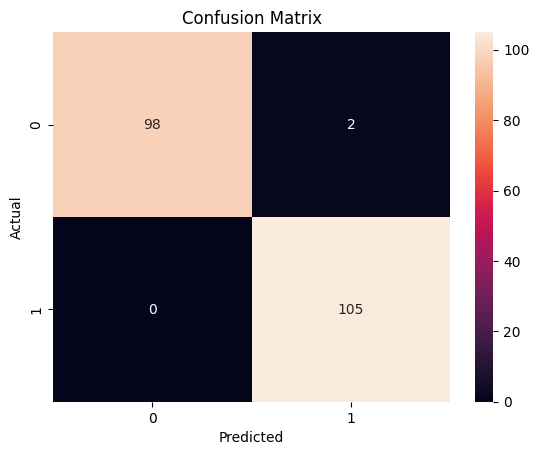

In [17]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

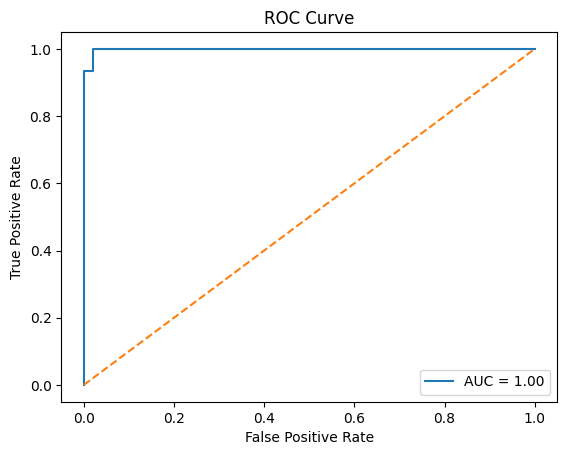

In [18]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

     Feature  Importance
2         cp    0.159608
11        ca    0.122267
7    thalach    0.107582
12      thal    0.106969
9    oldpeak    0.104616
0        age    0.084008
8      exang    0.083642
3   trestbps    0.066336
4       chol    0.064668
10     slope    0.046098
1        sex    0.029495
6    restecg    0.015604
5        fbs    0.009107


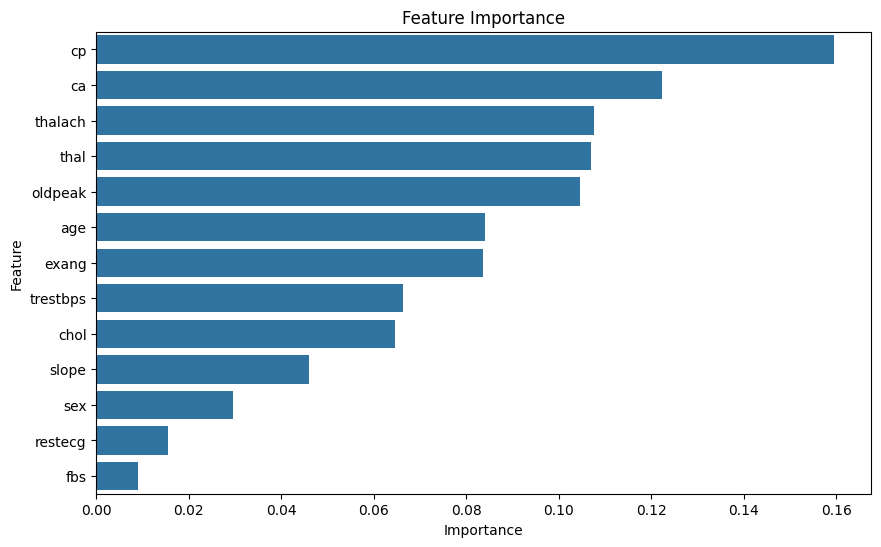

In [19]:
importances = model.feature_importances_

feat_imp = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(feat_imp)

plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=feat_imp)
plt.title("Feature Importance")
plt.show()

In [20]:
def predict_patient(data):

    data_df = pd.DataFrame([data], columns=X.columns)


    data_scaled = scaler.transform(data_df)


    pred = model.predict(data_scaled)[0]
    prob = model.predict_proba(data_scaled)[0]

    if pred == 1:
        result = " Disease "
    else:
        result = "No Disease"

    return {
        "result": result,
        "no_disease": prob[0],
        "disease": prob[1]
    }

In [21]:
print(" Input Data:\n")

age = float(input("Age: "))
sex = int(input("Sex (1=Male, 0=Female): "))
cp = int(input("Chest Pain Type (0-3): "))
trestbps = float(input("Resting Blood Pressure: "))
chol = float(input("Cholesterol: "))
fbs = int(input("Fasting Blood Sugar (1=True, 0=False): "))
restecg = int(input("Rest ECG (0-2): "))
thalach = float(input("Max Heart Rate: "))
exang = int(input("Exercise Angina (1=Yes, 0=No): "))
oldpeak = float(input("Oldpeak: "))
slope = int(input("Slope (0-2): "))
ca = int(input("Number of Vessels (0-3): "))
thal = int(input("Thal (1=Normal, 2=Fixed, 3=Reversible): "))

new_patient = [
    age, sex, cp, trestbps, chol, fbs,
    restecg, thalach, exang, oldpeak,
    slope, ca, thal
]

 Input Data:

Age: 44
Sex (1=Male, 0=Female): 0
Chest Pain Type (0-3): 2
Resting Blood Pressure: 220
Cholesterol: 220
Fasting Blood Sugar (1=True, 0=False): 1
Rest ECG (0-2): 2
Max Heart Rate: 220
Exercise Angina (1=Yes, 0=No): 1
Oldpeak: 220
Slope (0-2): 1
Number of Vessels (0-3): 1
Thal (1=Normal, 2=Fixed, 3=Reversible): 1


In [22]:
result = predict_patient(new_patient)

print("\n" + "="*40)
print(" HEART DISEASE PREDICTION")
print("="*40)

print(f" Result: {result['result']}")

print("\n Probabilities:")
print(f" No Disease: {result['no_disease']*100:.2f}%")
print(f" Disease: {result['disease']*100:.2f}%")

print("="*40)


 HEART DISEASE PREDICTION
 Result: No Disease

 Probabilities:
 No Disease: 55.39%
 Disease: 44.61%


In [23]:
import joblib

joblib.dump(model, "model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']